# ModelBuilding and Training

In [1]:
#auto reloading enabled
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold

import sys
import os
sys.path.append(os.path.abspath('../'))
from src.preprocessing import FeatureEngineerTransform, DataFrameLabelEncoder, scale_features, evaluate
from src.constants import NUMERICAL_COLS, CATEGORICAL_COLS, TARGET_COL, COLUMN_NAMES


from src.model_training import prepare_and_split_data, optimize_threshold, evaluate_with_cv

In [3]:
credit_df = pd.read_csv('../data/raw/creditcard.csv')
credit_df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [4]:
fraud_df = pd.read_csv("../data/processed/fraud_mapped.csv")
fraud_df.head(3)

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,ip_int,country,signup_to_purchase_time,immediate_purchase,device_sharing_count,ip_sharing_count
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0,732758368,Japan,4506682.0,0,1,1
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0,350311387,United States,17944.0,0,1,1
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1,2621473820,United States,1.0,1,12,12


## Train-Test Split

In [5]:
X_fraud_temp, X_fraud_test, y_fraud_temp, y_fraud_test = prepare_and_split_data(
    df=fraud_df, 
    target_column='class'
)

# 3. Verify it worked by inspecting the unpacked variables
print("\nSuccessfully loaded variables into the notebook context:")
print(f"Fraud Features training set sample dimension: {X_fraud_temp.shape}")


--- Distribution Summary for Target: 'class' ---
Train Shape: (120889, 16) | Test Shape: (30223, 16)
Train class ratios:
 {0: 0.9063521081322535, 1: 0.09364789186774644}
Test class ratios:
 {0: 0.9063627039010026, 1: 0.09363729609899746}

Successfully loaded variables into the notebook context:
Fraud Features training set sample dimension: (120889, 16)


In [6]:
# Second split: Separate remaining data into Train (75% of temp -> 60% total) and Validation (25% of temp -> 20% total)
from sklearn.model_selection import train_test_split


x_fraud_train, x_fraud_val, y_fraud_train, y_fraud_val = train_test_split(
    X_fraud_temp, y_fraud_temp, test_size=0.25, random_state=42, stratify=y_fraud_temp
)

print(f"Train size: {x_fraud_train.shape[0]} | Val size: {x_fraud_val.shape[0]} | Test size: {X_fraud_test.shape[0]}")

Train size: 90666 | Val size: 30223 | Test size: 30223


In [7]:
X_credit_temp, X_credit_test, y_credit_temp, y_credit_test = prepare_and_split_data(
    df=credit_df, 
    target_column='Class'
)

# 3. Verify it worked by inspecting the unpacked variables
print("\nSuccessfully loaded variables into the notebook context:")
print(f"Credit Features training set sample dimension: {X_credit_temp.shape}")


--- Distribution Summary for Target: 'Class' ---
Train Shape: (227845, 30) | Test Shape: (56962, 30)
Train class ratios:
 {0: 0.9982707542408216, 1: 0.001729245759178389}
Test class ratios:
 {0: 0.9982795547909132, 1: 0.0017204452090867595}

Successfully loaded variables into the notebook context:
Credit Features training set sample dimension: (227845, 30)


In [8]:
# Second split: Separate remaining data into Train (75% of temp -> 60% total) and Validation (25% of temp -> 20% total)

x_credit_train, x_credit_val, y_credit_train, y_credit_val = train_test_split(
    X_credit_temp, y_credit_temp, test_size=0.25, random_state=42, stratify=y_credit_temp
)

print(f"Train size: {x_credit_train.shape[0]} | Val size: {x_credit_val.shape[0]} | Test size: {X_credit_test.shape[0]}")

Train size: 170883 | Val size: 56962 | Test size: 56962


## Feature Scaling

In [9]:
# Initialize a fresh scaler instance for each distinct dataset
scaler_fraud = StandardScaler()

scaler_credit = StandardScaler()

In [10]:
columns_to_drop = ['signup_time', 'purchase_time', 'device_id', 'source', 'browser', 'sex', 'country', 'user_id']

# Isolate the final list of numeric columns we ACTUALLY want to scale and use
numeric_cols_fraud = [
    col for col in x_fraud_train.columns 
    if pd.api.types.is_numeric_dtype(x_fraud_train[col]) and col not in columns_to_drop
]

# Create clean, scaled dataframes keeping only the features we care about
X_fraud_train_scaled = pd.DataFrame(
    scaler_fraud.fit_transform(x_fraud_train[numeric_cols_fraud]),
    columns=numeric_cols_fraud,
    index=x_fraud_train.index
)

# ONLY transform the test data using the exact same columns
X_fraud_test_scaled = pd.DataFrame(
    scaler_fraud.transform(X_fraud_test[numeric_cols_fraud]),
    columns=numeric_cols_fraud,
    index=X_fraud_test.index
)

X_fraud_val_scaled = pd.DataFrame(
    scaler_fraud.transform(x_fraud_val[numeric_cols_fraud]),
    columns=numeric_cols_fraud,
    index=x_fraud_val.index
)

# 2. SCALING CREDIT CARD DATA 
numeric_cols_credit = x_credit_train.select_dtypes(include=['number']).columns

X_credit_train_scaled = x_credit_train.copy()
X_credit_train_scaled[numeric_cols_credit] = scaler_credit.fit_transform(x_credit_train[numeric_cols_credit])

X_credit_test_scaled = X_credit_test.copy()
X_credit_test_scaled[numeric_cols_credit] = scaler_credit.transform(X_credit_test[numeric_cols_credit])

# === ADD THIS LINE: Scale the validation data too! ===
X_credit_val_scaled = x_credit_val.copy()
X_credit_val_scaled[numeric_cols_credit] = scaler_credit.transform(x_credit_val[numeric_cols_credit])

## Linear Regression by SMOTE

Before SMOTE: {0: np.int64(82175), 1: np.int64(8491)}
After SMOTE:  {0: np.int64(82175), 1: np.int64(41087)}
Created 32596 SYNTHETIC Default loans
These are new, unique loans — not copies of existing ones

=== SMOTE ===  (best threshold: 0.91)
  Recall    : 54.56%  ← % of real defaults caught
  Precision : 98.28%  ← % of alerts that are real
  F1-Score  : 0.7017
  AUC-PR    : 0.6984  ← primary metric (threshold-independent)
  AUC-ROC   : 0.8446


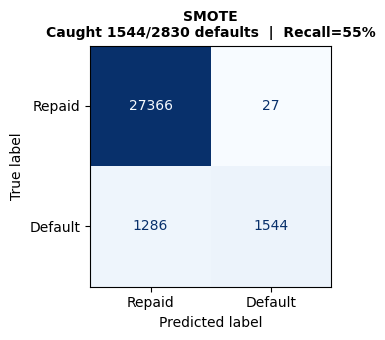

In [11]:
SEED =42
smote = SMOTE(
    sampling_strategy=0.5,  # same target ratio as oversampling
    k_neighbors=5,          # how many nearest neighbours to interpolate between
    random_state=SEED
)
x_fraud_smote, y_fraud_smote = smote.fit_resample(X_fraud_train_scaled, y_fraud_train)

print('Before SMOTE:', dict(pd.Series(y_fraud_train).value_counts()))
print('After SMOTE: ', dict(pd.Series(y_fraud_smote).value_counts()))
print(f'Created {y_fraud_smote.sum() - y_fraud_train.sum()} SYNTHETIC Default loans')
print('These are new, unique loans — not copies of existing ones')

lr_fraud = LogisticRegression(random_state=SEED, max_iter=1000)
lr_fraud.fit(x_fraud_smote, y_fraud_smote)

fraud_result_smote = evaluate('SMOTE', lr_fraud, X_fraud_val_scaled, y_fraud_val)


Before SMOTE: {0: np.int64(170588), 1: np.int64(295)}
After SMOTE:  {0: np.int64(170588), 1: np.int64(85294)}
Created 84999 SYNTHETIC Default loans
These are new, unique loans — not copies of existing ones

=== Balanced LR ===  (best threshold: 1.00)
  Recall    : 71.72%  ← % of real defaults caught
  Precision : 82.56%  ← % of alerts that are real
  F1-Score  : 0.7676
  AUC-PR    : 0.6807  ← primary metric (threshold-independent)
  AUC-ROC   : 0.9747


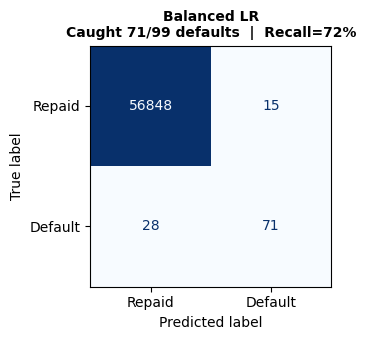

In [12]:
smote = SMOTE(
    sampling_strategy=0.5,  # same target ratio as oversampling
    k_neighbors=5,          # how many nearest neighbours to interpolate between
    random_state=SEED
)
x_credit_smote, y_credit_smote = smote.fit_resample(X_credit_train_scaled, y_credit_train)

print('Before SMOTE:', dict(pd.Series(y_credit_train).value_counts()))
print('After SMOTE: ', dict(pd.Series(y_credit_smote).value_counts()))
print(f'Created {y_credit_smote.sum() - y_credit_train.sum()} SYNTHETIC Default loans')
print('These are new, unique loans — not copies of existing ones')

# Drop SMOTE entirely for this test and let the loss function handle weights
lr_credit_balanced = LogisticRegression(
    class_weight='balanced', 
    random_state=SEED, 
    max_iter=1000
)

# Initialize and fit the model using class weights
lr_credit_balanced = LogisticRegression(
    class_weight='balanced', 
    random_state=SEED, 
    max_iter=1000
)

# Train on the clean, scaled training data
lr_credit_balanced.fit(X_credit_train_scaled, y_credit_train)

# === FIX THIS: Evaluate using X_credit_val_scaled instead of x_credit_val ===
credit_result = evaluate('Balanced LR', lr_credit_balanced, X_credit_val_scaled, y_credit_val)

## Ensemble Models

In [13]:
models_to_run = {
    "Random Forest (Base)": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED, class_weight='balanced'),
    "Random Forest (Deep)": RandomForestClassifier(n_estimators=200, max_depth=20, random_state=SEED, class_weight='balanced'),
    
    "XGBoost (Shallow)": XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=SEED, scale_pos_weight=10),
    "XGBoost (Dense)": XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.05, random_state=SEED, scale_pos_weight=10),
    
    "LightGBM (Fast)": LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=SEED, class_weight='balanced'),
    "LightGBM (Deep)": LGBMClassifier(n_estimators=200, max_depth=10, learning_rate=0.05, random_state=SEED, class_weight='balanced')
}

In [14]:
print("=== Running Tree Models for Fraud Dataset ===")
fraud_cv_results = {}
for name, model in models_to_run.items():
    fraud_cv_results[name] = evaluate_with_cv(name, model, X_fraud_train_scaled, y_fraud_train)

# Convert to structured data table
df_fraud_results = pd.DataFrame(fraud_cv_results).T

=== Running Tree Models for Fraud Dataset ===
✓ Random Forest (Base) 5-Fold CV Completed. Mean F1: 0.7011
✓ Random Forest (Deep) 5-Fold CV Completed. Mean F1: 0.7013
✓ XGBoost (Shallow) 5-Fold CV Completed. Mean F1: 0.7009
✓ XGBoost (Dense) 5-Fold CV Completed. Mean F1: 0.7009
[LightGBM] [Info] Number of positive: 6792, number of negative: 65740
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003492 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 974
[LightGBM] [Info] Number of data points in the train set: 72532, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

In [15]:
print("\n=== Running Tree Models for Credit Card Dataset ===")
credit_cv_results = {}
for name, model in models_to_run.items():
    credit_cv_results[name] = evaluate_with_cv(name, model, X_credit_train_scaled, y_credit_train)

# Convert to structured data table
df_credit_results = pd.DataFrame(credit_cv_results).T


=== Running Tree Models for Credit Card Dataset ===
✓ Random Forest (Base) 5-Fold CV Completed. Mean F1: 0.8455
✓ Random Forest (Deep) 5-Fold CV Completed. Mean F1: 0.8679
✓ XGBoost (Shallow) 5-Fold CV Completed. Mean F1: 0.8595
✓ XGBoost (Dense) 5-Fold CV Completed. Mean F1: 0.8706
[LightGBM] [Info] Number of positive: 236, number of negative: 136470
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012246 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 136706, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [16]:
def format_results_table(df_results):
    formatted = pd.DataFrame()
    for metric in ['F1', 'Precision', 'Recall', 'ROC-AUC']:
        formatted[metric] = df_results.apply(
            lambda row: f"{row[f'{metric}_mean']:.4f} (±{row[f'{metric}_std']:.4f})", axis=1
        )
    return formatted

print("=== FINAL FRAUD DATASET CROSS-VALIDATION SUMMARY ===")
display(format_results_table(df_fraud_results))

print("\n=== FINAL CREDIT CARD DATASET CROSS-VALIDATION SUMMARY ===")
display(format_results_table(df_credit_results))

=== FINAL FRAUD DATASET CROSS-VALIDATION SUMMARY ===


,F1,Precision,Recall,ROC-AUC
Random Forest (Base),0.7011 (±0.0074),0.9888 (±0.0139),0.5433 (±0.0107),0.8417 (±0.0028)
Random Forest (Deep),0.7013 (±0.0077),0.9957 (±0.0041),0.5413 (±0.0095),0.8415 (±0.0035)
XGBoost (Shallow),0.7009 (±0.0075),0.9994 (±0.0013),0.5397 (±0.0090),0.8431 (±0.0042)
XGBoost (Dense),0.7009 (±0.0075),0.9989 (±0.0021),0.5399 (±0.0090),0.8406 (±0.0046)
LightGBM (Fast),0.7009 (±0.0075),0.9994 (±0.0013),0.5397 (±0.0089),0.8427 (±0.0050)
LightGBM (Deep),0.7008 (±0.0074),0.9987 (±0.0016),0.5399 (±0.0091),0.8438 (±0.0050)



=== FINAL CREDIT CARD DATASET CROSS-VALIDATION SUMMARY ===


,F1,Precision,Recall,ROC-AUC
Random Forest (Base),0.8455 (±0.0556),0.8858 (±0.0389),0.8169 (±0.1008),0.9720 (±0.0243)
Random Forest (Deep),0.8679 (±0.0574),0.9165 (±0.0344),0.8271 (±0.0840),0.9626 (±0.0252)
XGBoost (Shallow),0.8595 (±0.0589),0.9533 (±0.0300),0.7898 (±0.0992),0.9824 (±0.0160)
XGBoost (Dense),0.8706 (±0.0549),0.9352 (±0.0193),0.8203 (±0.0968),0.9845 (±0.0144)
LightGBM (Fast),0.8643 (±0.0542),0.9264 (±0.0277),0.8136 (±0.0823),0.9799 (±0.0175)
LightGBM (Deep),0.8703 (±0.0564),0.9394 (±0.0322),0.8169 (±0.0955),0.9726 (±0.0231)
